In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
estado = "selvagem" # mutante ou selvagem? qual mutante?
lig = "sem" # com ou sem RNA ?

In [30]:
#data = np.loadtxt(f"rmsd_{estado}_{lig}_rna.dat", skiprows=2) # se .dat pela extensão do vmd
data = np.loadtxt(f"rmsd_{estado}_{lig}_rna.dat")

frames = data[:, 0]
rmsd = data[:, 1]

df = pd.DataFrame(data, columns=["frame", "rmsd"])

In [31]:
# df.describe()

In [32]:
target = 200 # representar 20% dos frames da trajetória usada
best_width = None
best_peak = None
best_diff = np.inf

In [33]:
# escolher o melhor bin (bin_width) que gera um histograma
# cujo pico de frequência fica o mais próximo possível
# do alvo definido (200 frames)
# guardar o bin_width que mais se aproxima

for bw in np.arange(0.001, 2.0, 0.001):
    bins = np.arange(rmsd.min(), rmsd.max() + bw, bw)
    counts, edges = np.histogram(rmsd, bins=bins)
    peak = counts.max()
    diff = abs(peak - target)
    if diff < best_diff:
        best_diff = diff
        best_width = bw
        best_peak = peak

print(f"Melhor bin_width = {best_width:.3f}")
print(f"Pico = {best_peak} frames")

Melhor bin_width = 0.448
Pico = 200 frames


In [34]:
bins = np.arange(rmsd.min(), rmsd.max() + best_width, best_width)
counts, edges = np.histogram(rmsd, bins=bins)

In [35]:
# identificar a faixa de RMSD mais populosa
idx = np.argmax(counts)
lower = edges[idx]
upper = edges[idx+1]

In [36]:
print(f"Faixa de RMSD mais populosa: {lower:.2f} - {upper:.2f} Å")
print(f"Frames: {counts[idx]}")

Faixa de RMSD mais populosa: 5.82 - 6.27 Å
Frames: 200


In [37]:
max_bin_idx = np.argmax(counts)
lower = edges[max_bin_idx]
upper = edges[max_bin_idx + 1]
n_frames = counts[max_bin_idx]

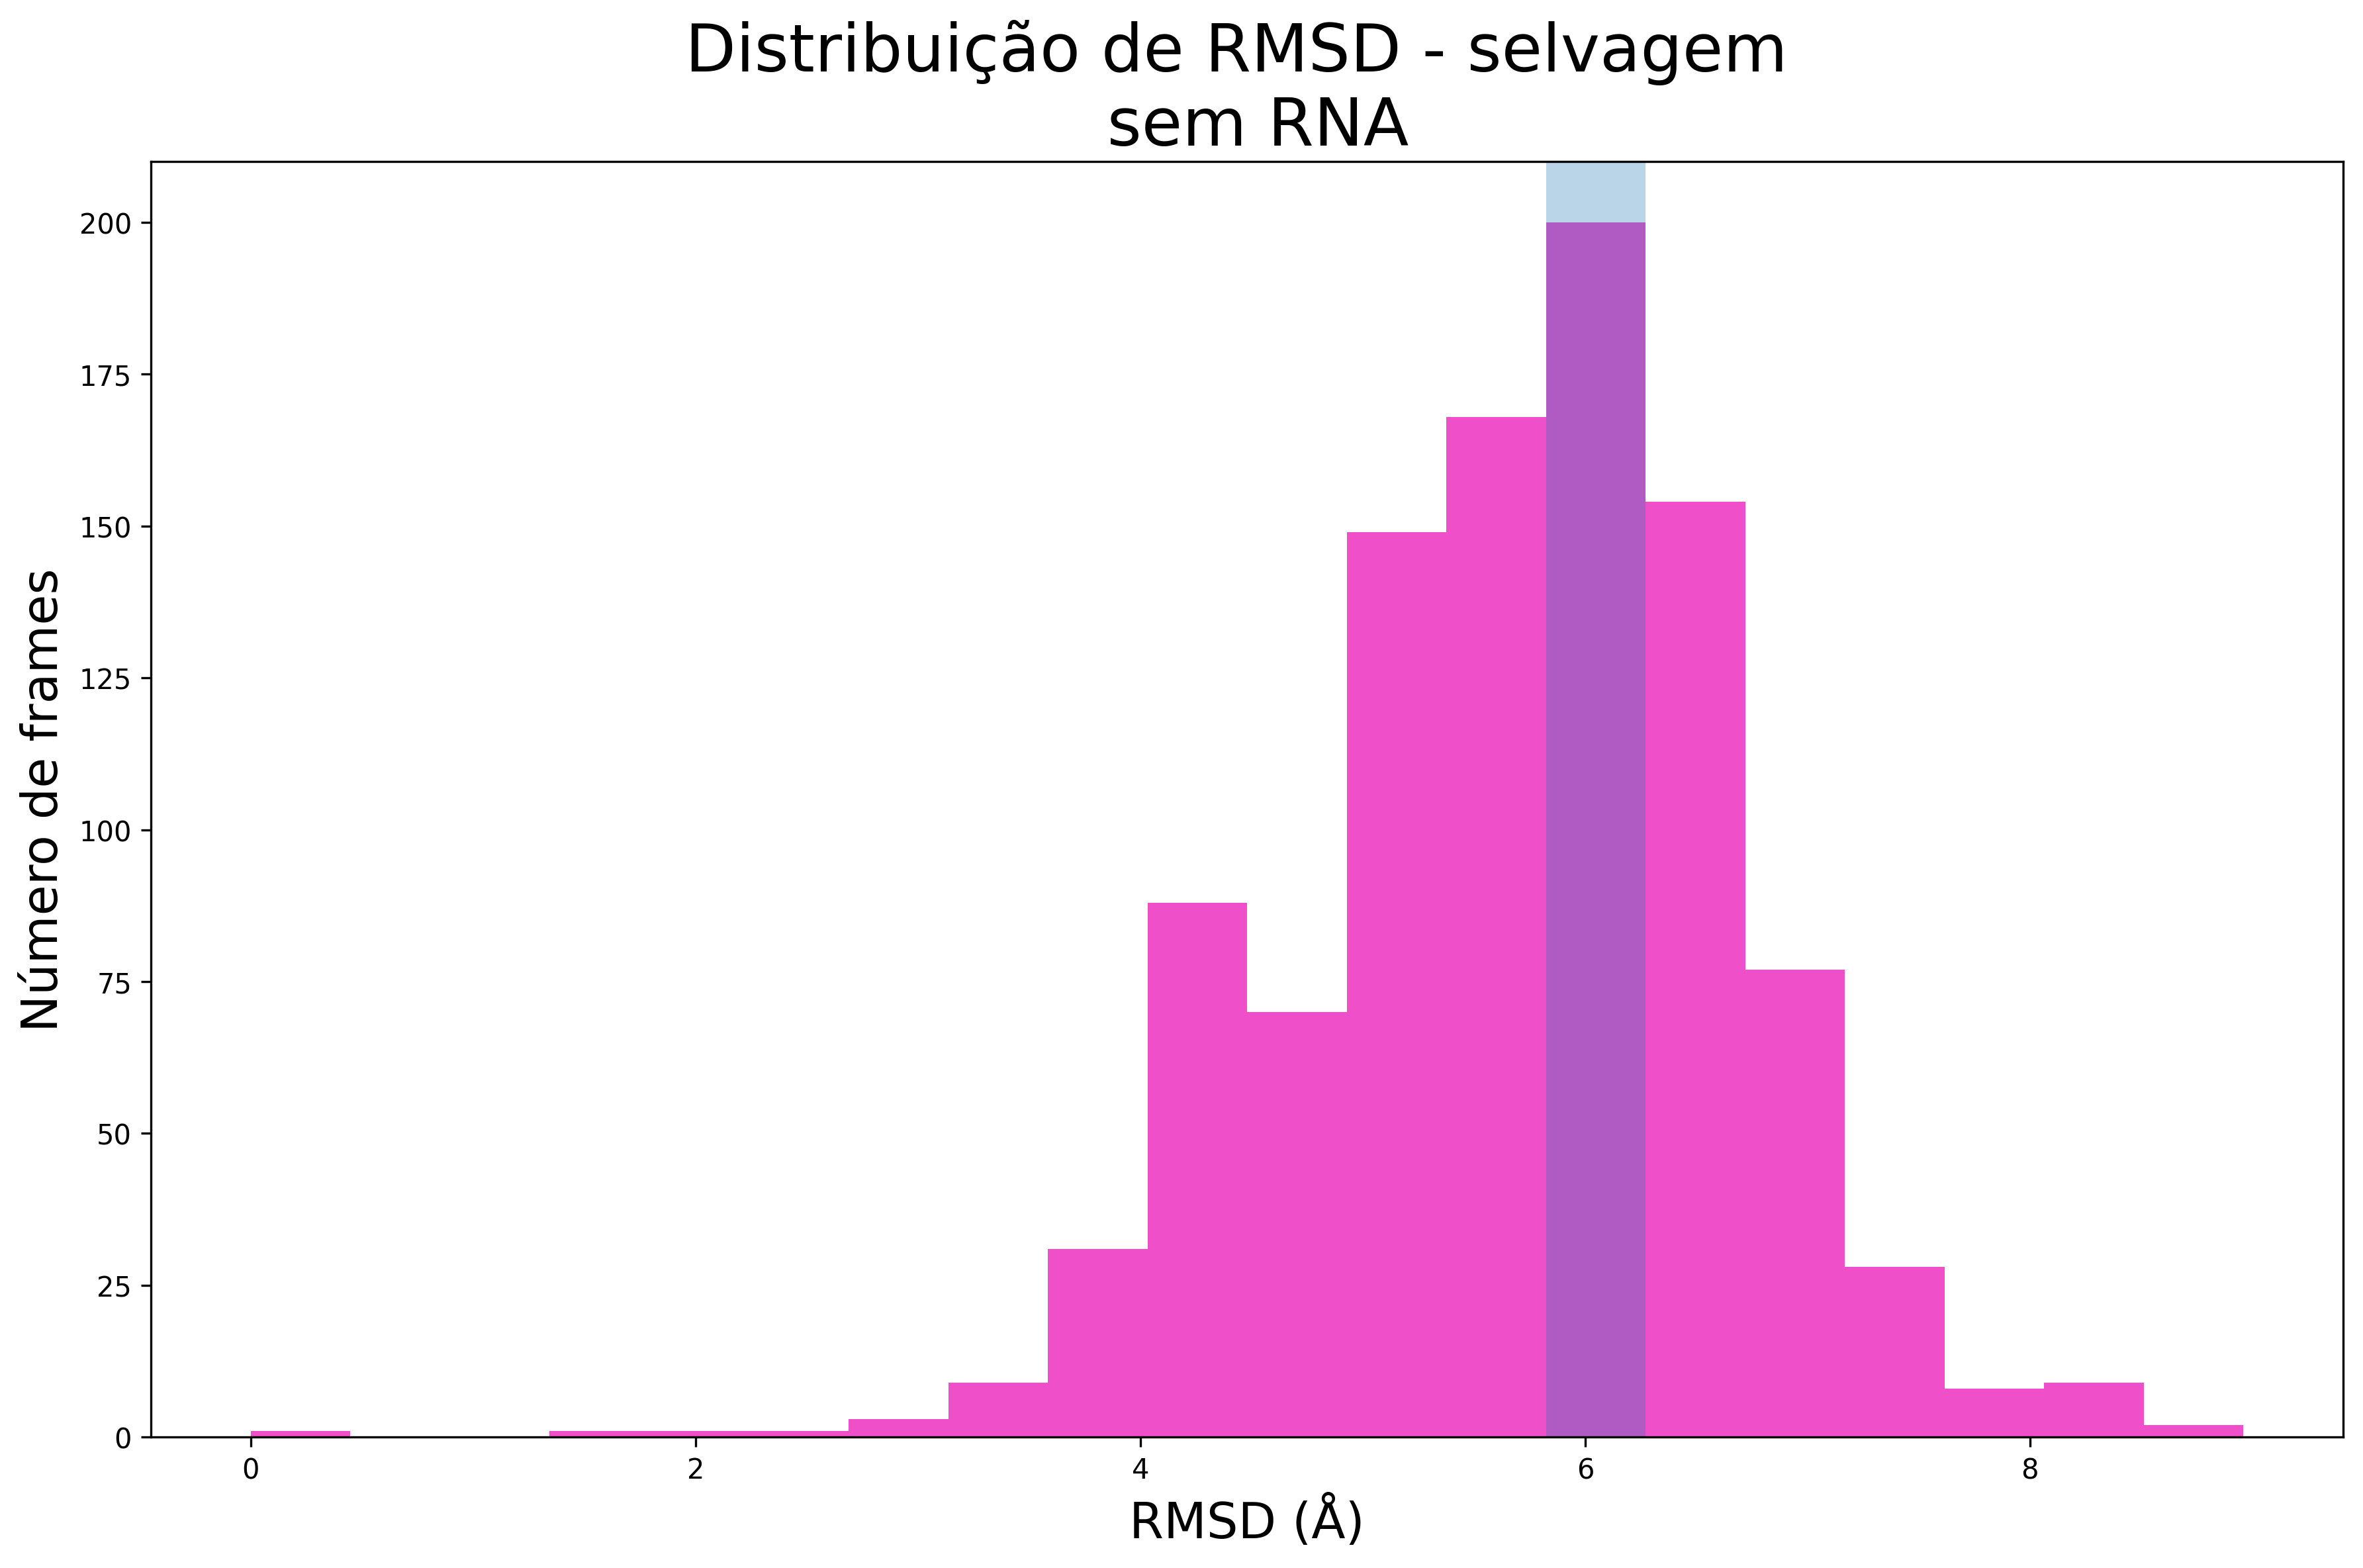

In [38]:
plt.figure(figsize=(12,8), dpi=300)
plt.hist(rmsd, bins=bins, color="#f04fca")
plt.xlabel("RMSD (Å)", fontsize=18)
plt.ylabel("Número de frames", fontsize=18)
plt.title(f"Distribuição de RMSD - {estado} \n {lig} RNA", fontsize=24)

# Destaca a faixa mais populosa
plt.axvspan(lower, upper, alpha=0.3)
plt.tight_layout()
plt.savefig(f"distribuicao_rmsd_{estado}_{lig}_rna.png", dpi=300)
plt.show()

In [39]:
# Selecionar apenas os frames dentro da faixa mais populosa
df_bin = df[(df["rmsd"] >= lower) & (df["rmsd"] < upper)]

In [40]:
# Mediana do RMSD nessa população
rmsd_mediano = df_bin["rmsd"].median()

In [41]:
# Frame cujo RMSD está mais próximo da mediana
idx_frame = (df_bin["rmsd"] - rmsd_mediano).abs().idxmin()

In [42]:
frame_escolhido = int(df_bin.loc[idx_frame, "frame"])
rmsd_escolhido = df_bin.loc[idx_frame, "rmsd"]

In [43]:
print(f"RMSD mediano da população: {rmsd_mediano:.3f} Å")
print(f"Frame escolhido: {frame_escolhido}")
print(f"RMSD do frame: {rmsd_escolhido:.3f} Å")

RMSD mediano da população: 6.049 Å
Frame escolhido: 324
RMSD do frame: 6.048 Å


In [44]:
with open(f"rmsd_histograma_{estado}_{lig}_rna.txt", "w") as f:
    f.write(
        f"Faixa de RMSD mais populosa: {lower:.2f} - {upper:.2f} Å\n"
        f"Frames: {counts[idx]}\n"
        f"RMSD mediano da população: {rmsd_mediano:.3f} Å\n"
        f"Frame escolhido: {frame_escolhido}\n"
        f"RMSD do frame: {rmsd_escolhido:.3f} Å"
    )

** Este script foi criado por Isabelle Pereira, Layla Rodrigues e Yolanda Marcello (22/06/2026)